<a href="https://colab.research.google.com/github/mvuddandi/Capstone_PatchTST/blob/main/Classifier_Long_Short.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! git clone https://github.com/mvuddandi/Capstone_PatchTST.git

fatal: destination path 'Capstone_PatchTST' already exists and is not an empty directory.


In [3]:
%cd /content/Capstone_PatchTST


/content/Capstone_PatchTST


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df_weather = pd.read_csv("/content/Capstone_PatchTST/weather.csv")

In [6]:
df_weather_t = df_weather[['date','T (degC)',]]
df_weather_t

,date,T (degC)
0,2020-01-01 00:10:00,0.71
1,2020-01-01 00:20:00,0.75
2,2020-01-01 00:30:00,0.73
3,2020-01-01 00:40:00,0.37
4,2020-01-01 00:50:00,0.33
...,...,...
52691,2020-12-31 23:20:00,2.28
52692,2020-12-31 23:30:00,2.13
52693,2020-12-31 23:40:00,1.99
52694,2020-12-31 23:50:00,2.07


In [7]:
mean_t = df_weather_t['T (degC)'].mean()
mean_t

np.float64(10.818240663427966)

In [8]:
std_dev_t = np.std(df_weather_t['T (degC)'])
std_dev_t

7.468599674061407

​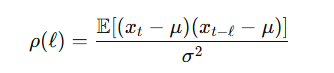

In [11]:
max_lag = 5000
x = df_weather_t['T (degC)'].values
var_t = x.var()
acf =[]

for l in range(1, max_lag + 1):

    products = []

    for t in range(l, len(x)):
        val = (x[t] - mean_t) * (x[t - l] - mean_t)
        products.append(val)

    avg_product = np.mean(products)
    rho_l = avg_product / var_t

    acf.append(rho_l)

acf




[np.float64(0.9994117610382761),
 np.float64(0.9981919467549747),
 np.float64(0.9966138834596109),
 np.float64(0.9946862254862291),
 np.float64(0.9924130461246502),
 np.float64(0.9897966825860591),
 np.float64(0.9868446498115798),
 np.float64(0.9835664969323641),
 np.float64(0.9799805623693271),
 np.float64(0.9761051783375134),
 np.float64(0.9719450366074558),
 np.float64(0.9675101910684286),
 np.float64(0.9628168295818389),
 np.float64(0.9578881609943051),
 np.float64(0.9527391166199879),
 np.float64(0.9473766902123564),
 np.float64(0.9418098656785805),
 np.float64(0.936051083947521),
 np.float64(0.9301168221502325),
 np.float64(0.924026780296347),
 np.float64(0.9178030317209094),
 np.float64(0.9114554702898237),
 np.float64(0.9049944570579406),
 np.float64(0.8984252911214459),
 np.float64(0.8917625893298051),
 np.float64(0.8850176429508778),
 np.float64(0.8782081448794956),
 np.float64(0.871347033542639),
 np.float64(0.8644480446376511),
 np.float64(0.8575206896585786),
 np.float64(0

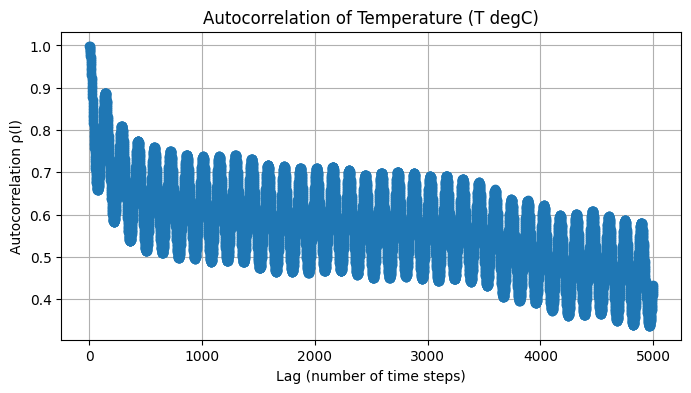

In [12]:

lags = range(1, len(acf) + 1)

plt.figure(figsize=(8, 4))
plt.plot(lags, acf, marker='o')
plt.xlabel("Lag (number of time steps)")
plt.ylabel("Autocorrelation ρ(l)")
plt.title("Autocorrelation of Temperature (T degC)")
plt.grid(True)
plt.show()


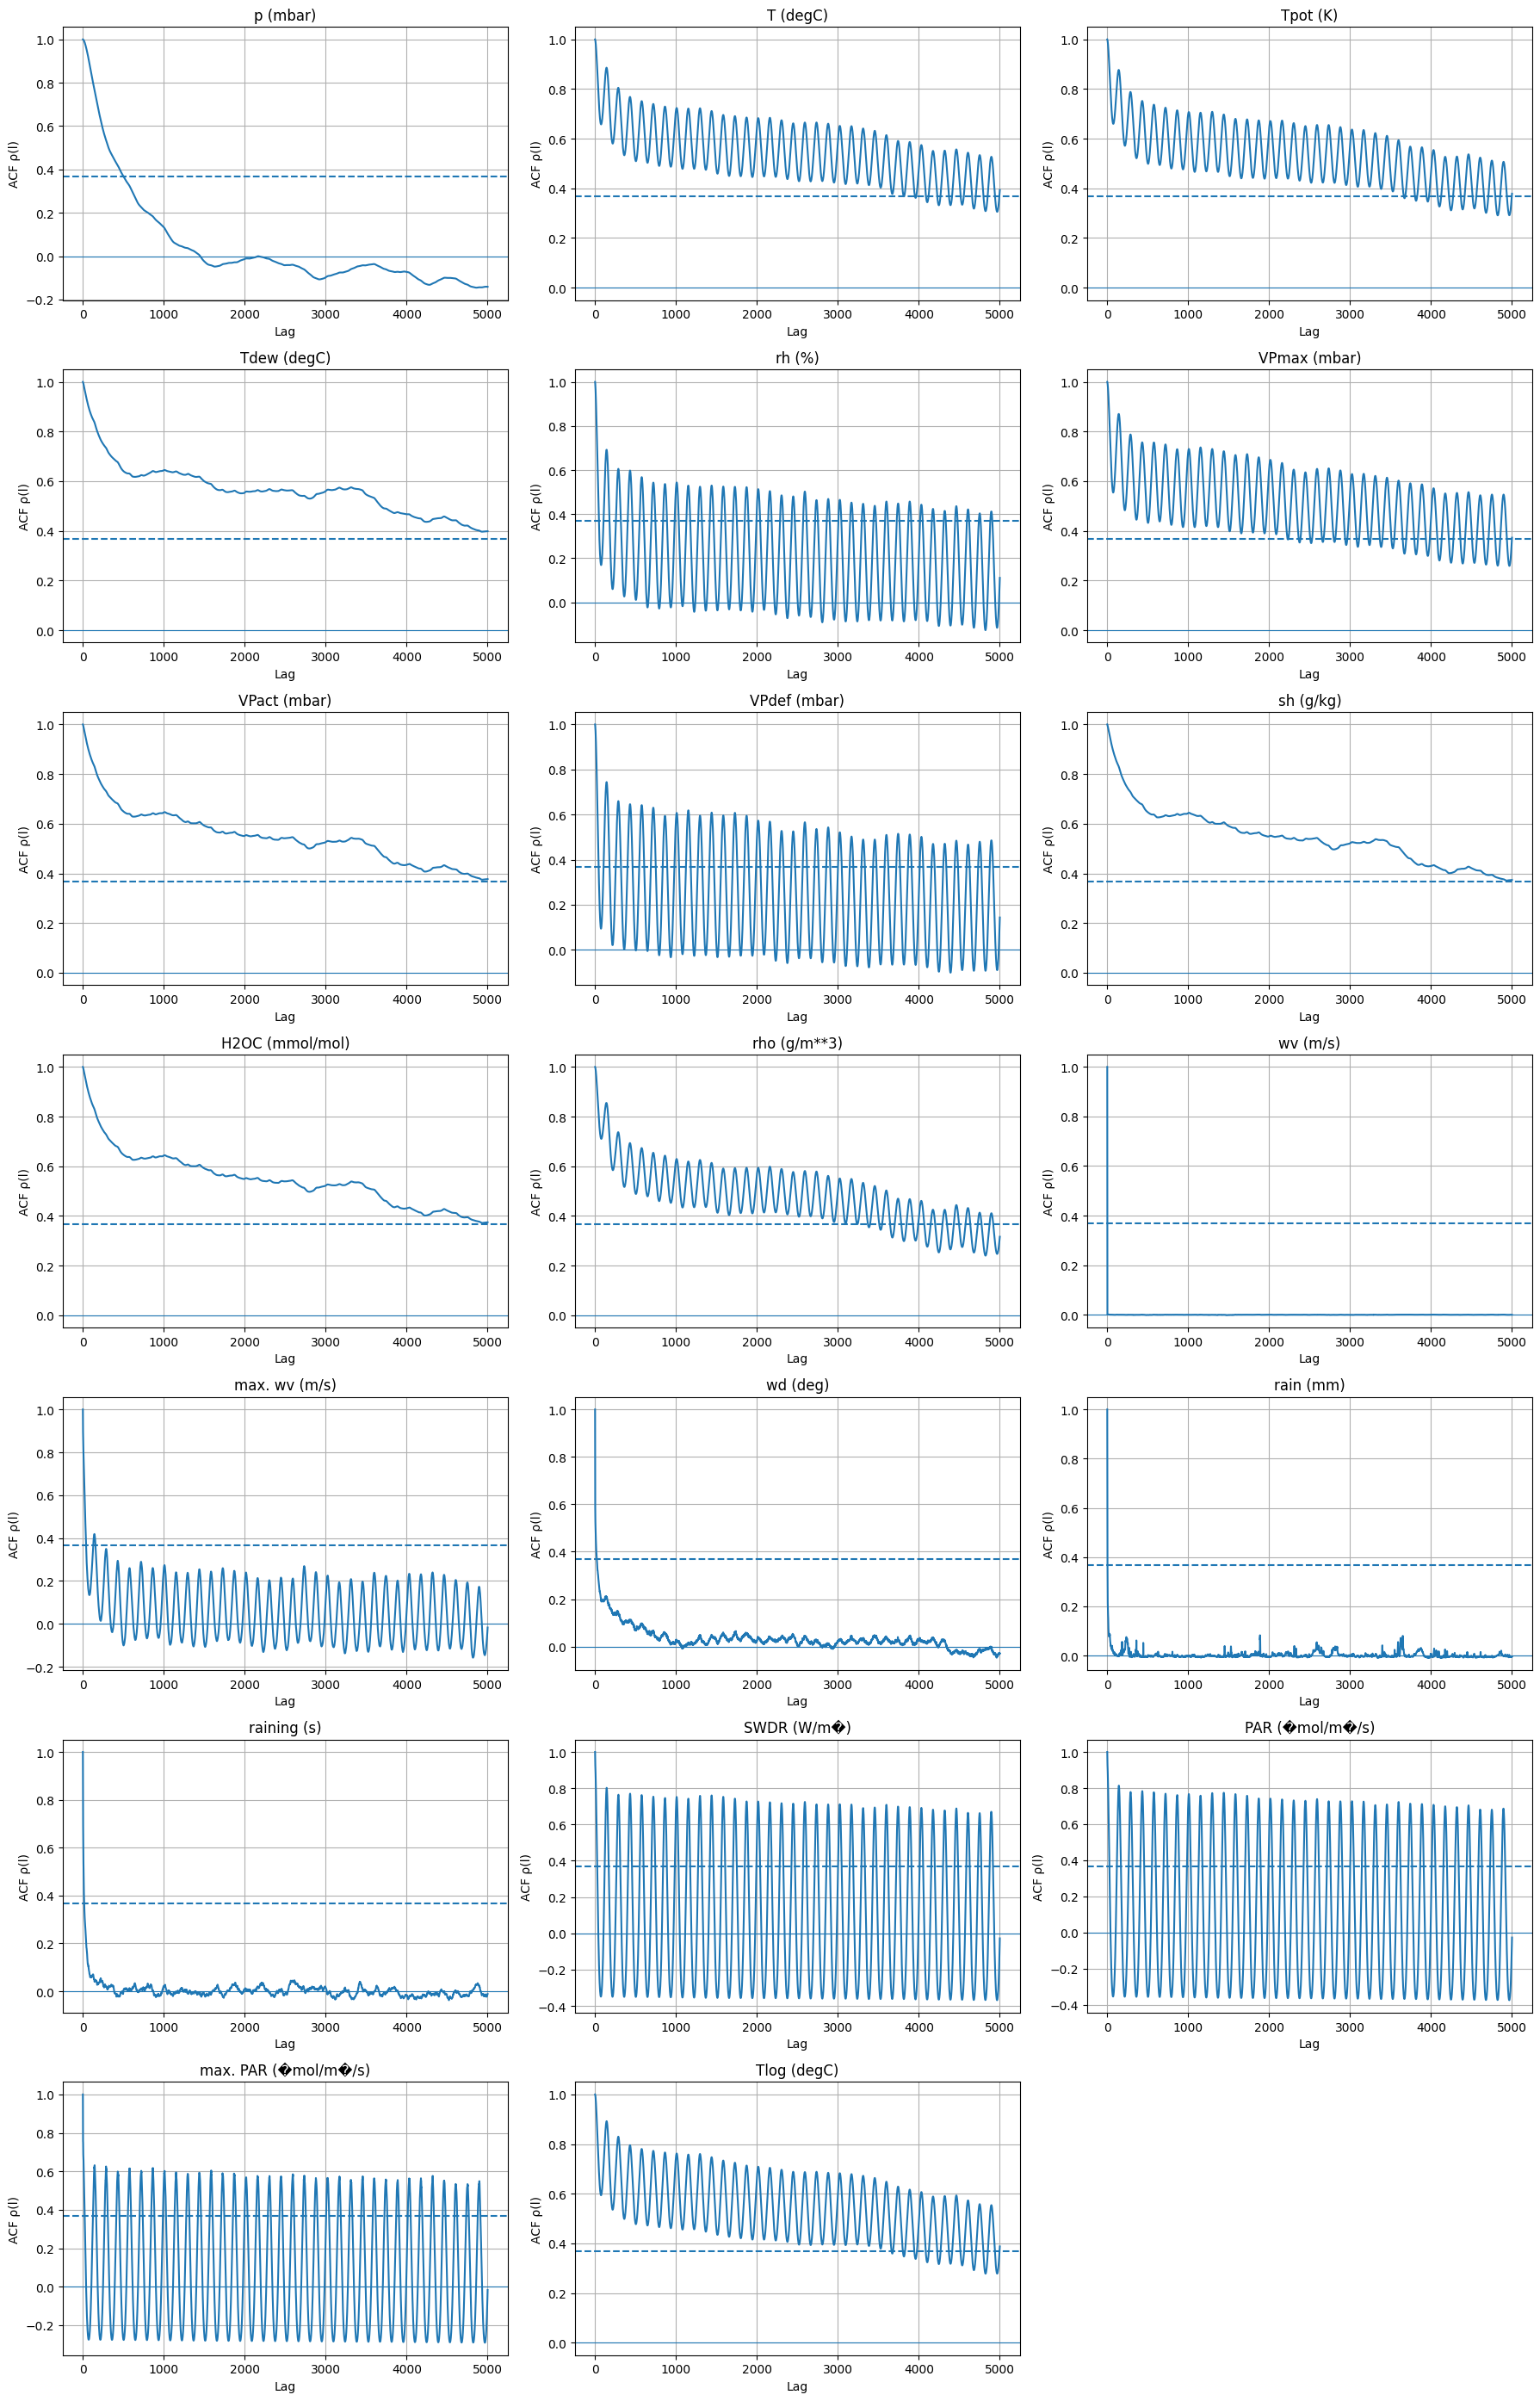

In [13]:

from statsmodels.tsa.stattools import acf as sm_acf

# =========================
# CONFIG
# =========================
CSV_PATH = "/content/Capstone_PatchTST/weather.csv"
TIME_COL_CANDIDATES = ["timestamp", "time", "date", "datetime", "ds"]

MAX_LAG = 5000          # increase/decrease (e.g., 500, 2000, 5000) based on your data length
N_COLS = 3              # how many plots per row
FIG_W = 18              # figure width
FIG_H_PER_ROW = 4       # height per row

DROP_COLS = {"OT"}      # optional: exclude known junk columns (edit if needed)

# =========================
# LOAD + SORT BY TIME (if available)
# =========================
df_weather = pd.read_csv(CSV_PATH)

time_col = None
for c in TIME_COL_CANDIDATES:
    if c in df_weather.columns:
        time_col = c
        break

if time_col:
    df_weather[time_col] = pd.to_datetime(df_weather[time_col], errors="coerce")
    df_weather = df_weather.sort_values(time_col)

# =========================
# PICK NUMERIC FEATURES
# =========================
num_cols = df_weather.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in DROP_COLS]

if not num_cols:
    raise ValueError("No numeric features found to compute ACF.")

# =========================
# COMPUTE + PLOT ACF FOR ALL FEATURES
# =========================
n_feats = len(num_cols)
n_rows = int(np.ceil(n_feats / N_COLS))

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(FIG_W, FIG_H_PER_ROW * n_rows), squeeze=False)

for idx, col in enumerate(num_cols):
    r, c = divmod(idx, N_COLS)
    ax = axes[r][c]

    x = df_weather[col].astype(float).replace([np.inf, -np.inf], np.nan)
    x = x.interpolate(limit_direction="both").dropna().values

    if len(x) < 10:
        ax.set_title(f"{col} (too few points)")
        ax.axis("off")
        continue

    nlags = min(MAX_LAG, len(x) - 2)
    if nlags < 1:
        ax.set_title(f"{col} (too short)")
        ax.axis("off")
        continue

    acf_vals = sm_acf(x, nlags=nlags, fft=True)
    lags = np.arange(len(acf_vals))

    ax.plot(lags, acf_vals)
    ax.axhline(1/np.e, linestyle="--")  # e^-1 ≈ 0.37 reference line
    ax.axhline(0.0, linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF ρ(l)")
    ax.grid(True)

# turn off extra subplots
for j in range(n_feats, n_rows * N_COLS):
    r, c = divmod(j, N_COLS)
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()
